# ```Are Prices Justified? - IPL 2026```

In [44]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

In [45]:
batters = pd.read_csv(r"C:\Users\Rano's PC\Machine\InsightForge\InsightForge\Are Prices Justified - IPL 2026\_dataset\_cleaned_data\batters.csv")
bowlers = pd.read_csv(r"C:\Users\Rano's PC\Machine\InsightForge\InsightForge\Are Prices Justified - IPL 2026\_dataset\_cleaned_data\bowlers.csv")

In [46]:
batters.head()

,pos,player,runs,mat,inns,no,sr,boundary_pct,avg_balls_inns,base_price,final_price,role,final_price_rate
0,71,Abdul Samad,116,8,8,2,131.81,60.34,11.00,3000000,42000000,Uncapped,14.0
1,8,Abhishek Sharma,563,15,15,1,204.72,81.35,18.33,2000000,65000000,Capped,32.5
2,156,Adam Milne,2,1,1,1,100.00,0.00,2.00,20000000,24000000,Capped,1.2
3,46,Aiden Markram,231,12,11,2,138.32,63.20,15.18,20000000,20000000,Capped,1.0
4,27,Ajinkya Rahane,335,14,14,1,135.08,62.09,17.71,15000000,15000000,Capped,1.0


In [47]:
bowlers.head()

,pos,player,wkts,mat,inns,ov,runs,avg,econ,sr,base_price,final_price,role,final_price_rate
0,75,Abhinandan Singh,3,3,3,9.4,122,40.66,12.62,19.33,3000000,3000000,Uncapped,1.00
1,72,Akash Singh,4,2,2,7.0,80,20.00,11.42,10.50,3000000,3000000,Uncapped,1.00
2,44,Akeal Hosein,8,7,7,24.4,198,24.75,8.02,18.50,20000000,20000000,Capped,1.00
3,5,Anshul Kamboj,21,14,14,50.2,530,25.23,10.52,14.38,3000000,34000000,Uncapped,11.33
4,39,Anukul Roy,9,14,12,27.1,261,29.00,9.60,18.11,3000000,4000000,Uncapped,1.33


In [48]:
batters = batters[batters['inns']>5]

In [49]:
bowlers = bowlers[bowlers['inns']>5]

In [50]:
batters.head()

,pos,player,runs,mat,inns,no,sr,boundary_pct,avg_balls_inns,base_price,final_price,role,final_price_rate
0,71,Abdul Samad,116,8,8,2,131.81,60.34,11.00,3000000,42000000,Uncapped,14.0
1,8,Abhishek Sharma,563,15,15,1,204.72,81.35,18.33,2000000,65000000,Capped,32.5
3,46,Aiden Markram,231,12,11,2,138.32,63.20,15.18,20000000,20000000,Capped,1.0
4,27,Ajinkya Rahane,335,14,14,1,135.08,62.09,17.71,15000000,15000000,Capped,1.0
7,20,Angkrish Raghuvanshi,422,13,12,2,146.52,64.93,24.00,3000000,30000000,Uncapped,10.0


In [51]:
bowlers.head()

,pos,player,wkts,mat,inns,ov,runs,avg,econ,sr,base_price,final_price,role,final_price_rate
2,44,Akeal Hosein,8,7,7,24.4,198,24.75,8.02,18.50,20000000,20000000,Capped,1.00
3,5,Anshul Kamboj,21,14,14,50.2,530,25.23,10.52,14.38,3000000,34000000,Uncapped,11.33
4,39,Anukul Roy,9,14,12,27.1,261,29.00,9.60,18.11,3000000,4000000,Uncapped,1.33
6,21,Arshdeep Singh,14,14,14,53.0,541,38.64,10.20,22.71,20000000,180000000,Capped,9.00
7,55,Ashok Sharma,6,6,6,21.0,228,38.00,10.85,21.00,3000000,9000000,Uncapped,3.00


## 4.Data Analysis

### 4.1 Univariate Analysis

**BATTERS**

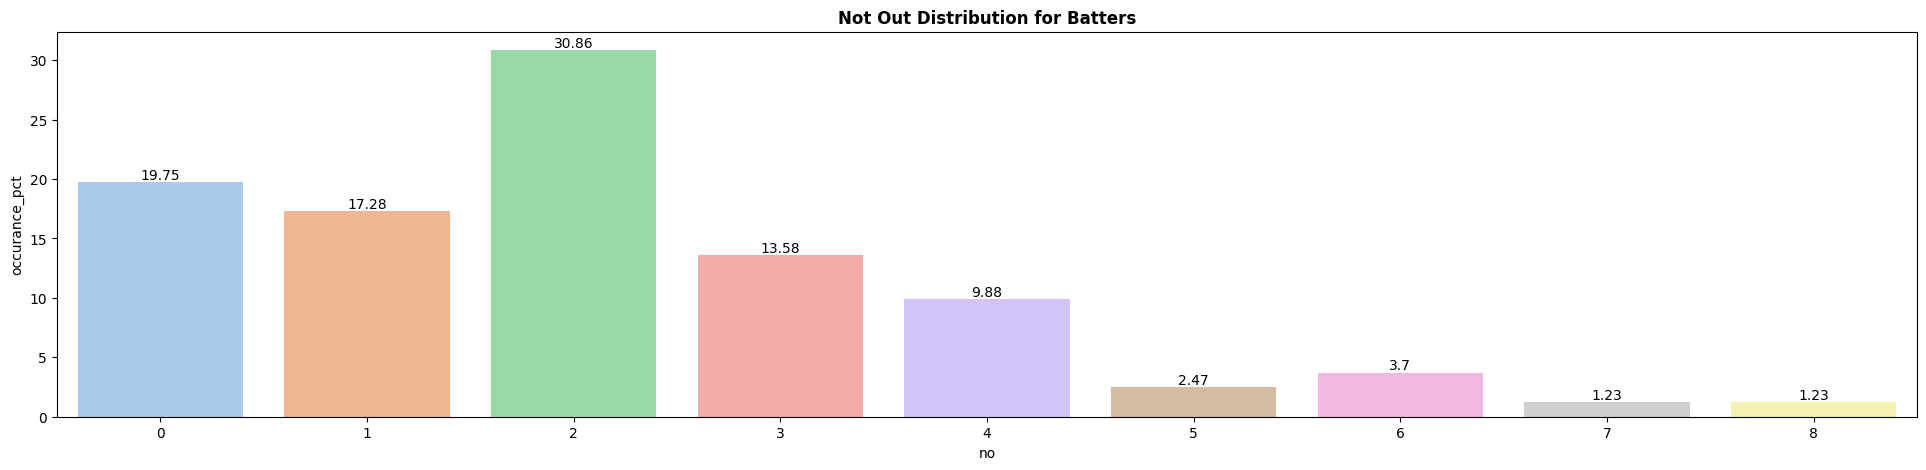

In [53]:
no_dist = batters['no'].value_counts(normalize=True).mul(100).reset_index(name = 'occurance_pct').round(2)


plt.figure(figsize=(24,5))
ax = sns.barplot(y = 'occurance_pct',x= 'no',data = no_dist,palette='pastel')
for conatiner in ax.containers:
    ax.bar_label(container=conatiner)
plt.title("Not Out Distribution for Batters",weight = 'bold')
plt.show()

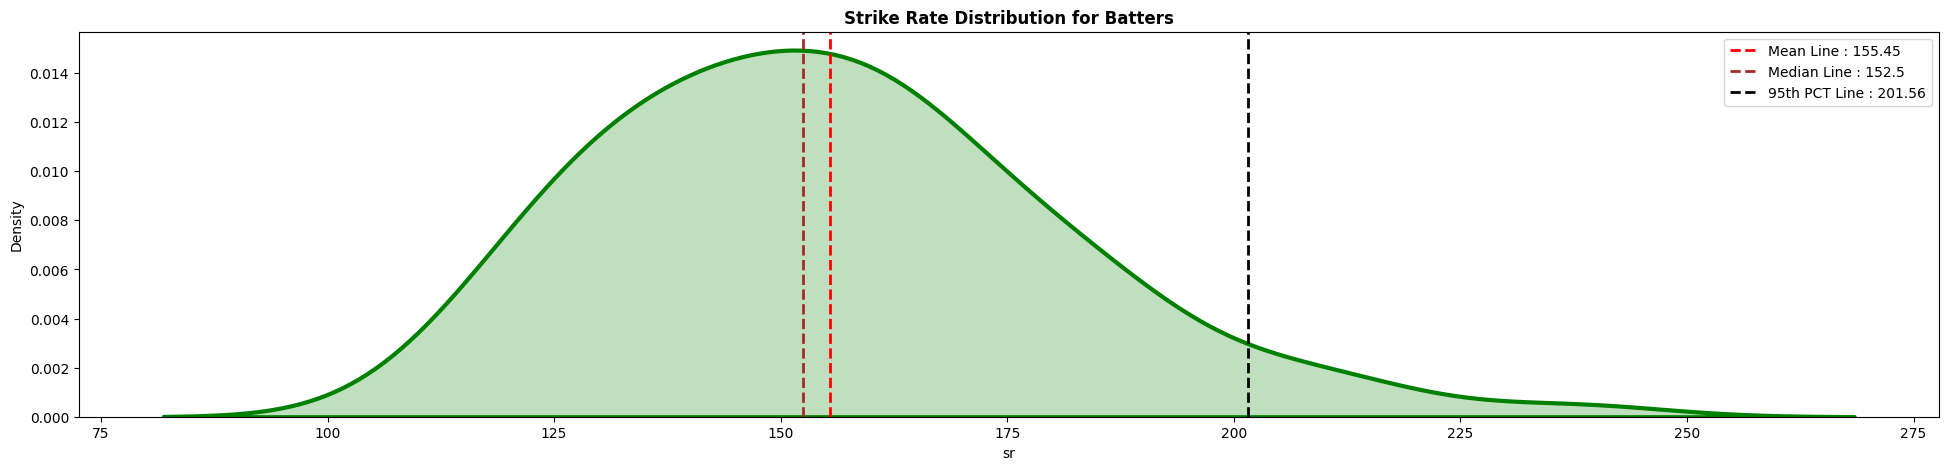

In [ ]:
plt.figure(figsize=(24,5))
sns.kdeplot(x ='sr',
            data = batters,
            linewidth = 3,
            fill=True,
            color='green',
            )
plt.axvline(batters['sr'].mean(),color = 'red',linestyle = '--',linewidth = 2,label = f"Mean Line : {batters['sr'].mean().round(2)}")
plt.axvline(batters['sr'].median(),color = 'brown',linestyle = '--',linewidth = 2,label = f"Median Line : {batters['sr'].median().round(2)}")
plt.axvline(batters['sr'].quantile(.95),color = 'black',linestyle = '--',linewidth = 2,label = f"95th PCT Line : {batters['sr'].quantile(.95).round(2)}")


plt.title("Strike Rate Distribution for Batters",weight = 'bold')
plt.grid(False)
plt.legend()
plt.show()

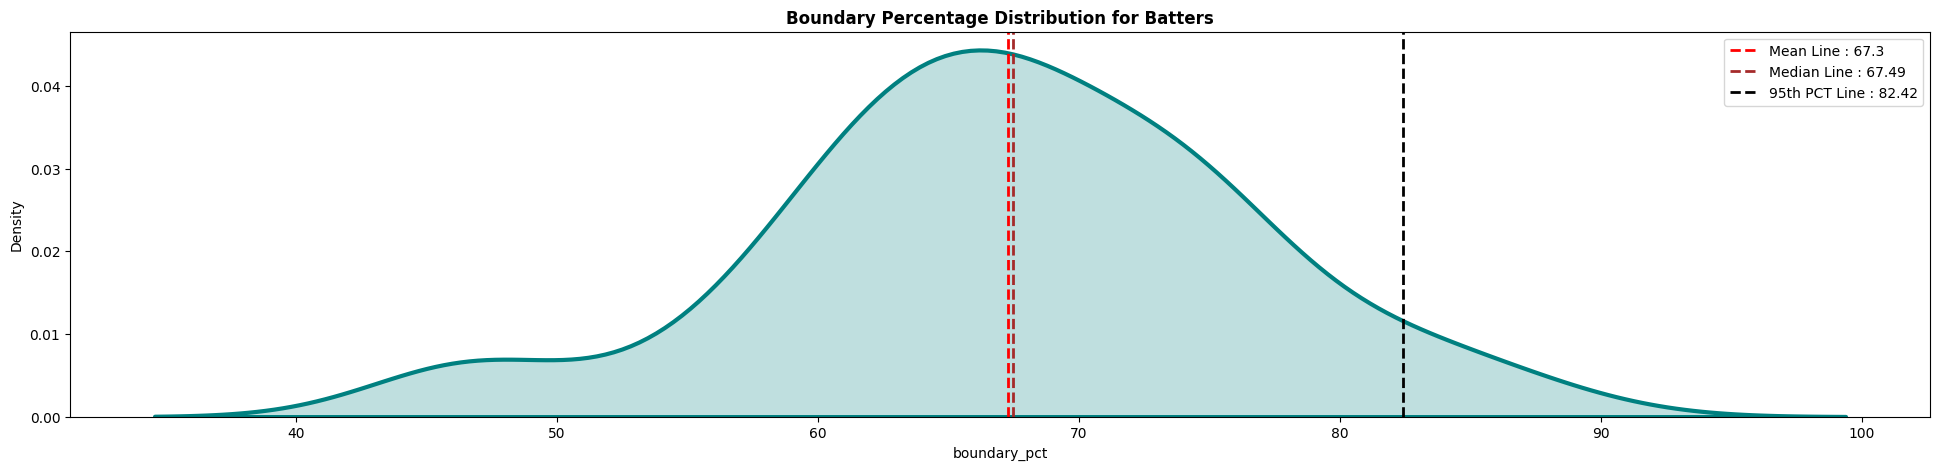

In [58]:
plt.figure(figsize=(24,5))
sns.kdeplot(x ='boundary_pct',
            data = batters,
            linewidth = 3,
            fill=True,
            color='teal',
            )
plt.axvline(batters['boundary_pct'].mean(),color = 'red',linestyle = '--',linewidth = 2,label = f"Mean Line : {batters['boundary_pct'].mean().round(2)}")
plt.axvline(batters['boundary_pct'].median(),color = 'brown',linestyle = '--',linewidth = 2,label = f"Median Line : {batters['boundary_pct'].median().round(2)}")
plt.axvline(batters['boundary_pct'].quantile(.95),color = 'black',linestyle = '--',linewidth = 2,label = f"95th PCT Line : {batters['boundary_pct'].quantile(.95).round(2)}")


plt.title("Boundary Percentage Distribution for Batters",weight = 'bold')
plt.grid(False)
plt.legend()
plt.show()

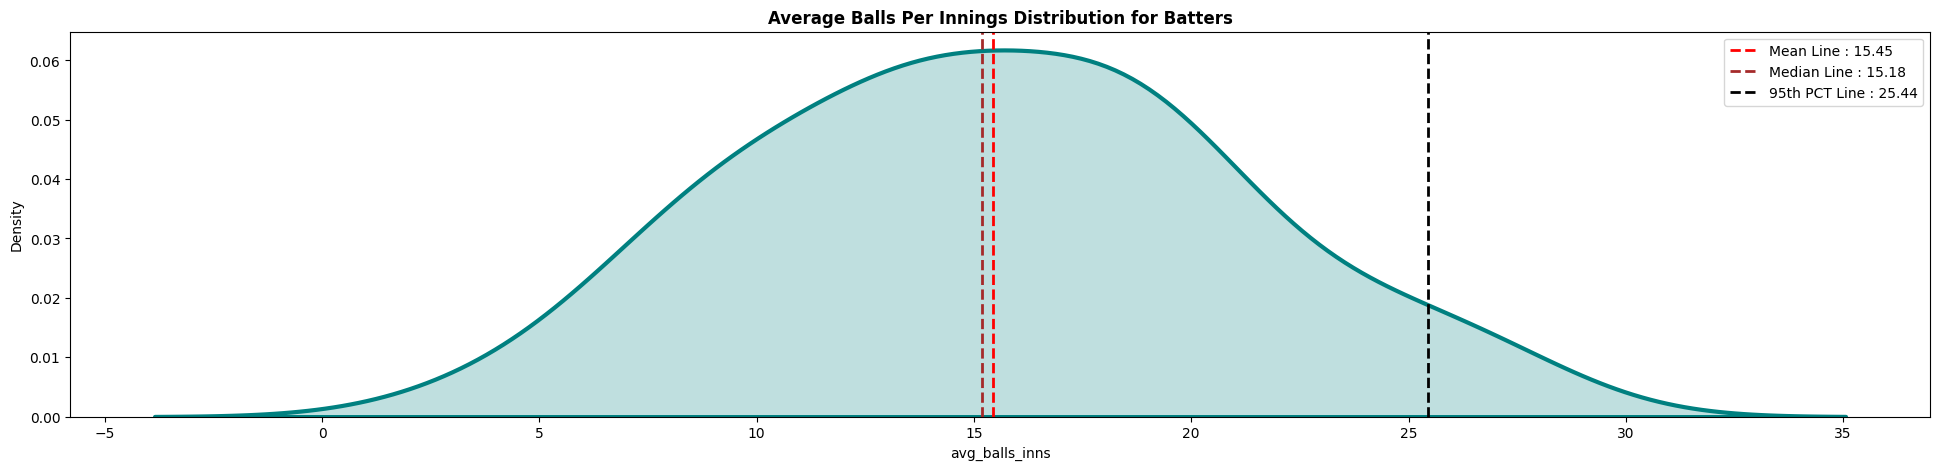

In [59]:
plt.figure(figsize=(24,5))
sns.kdeplot(x ='avg_balls_inns',
            data = batters,
            linewidth = 3,
            fill=True,
            color='teal',
            )
plt.axvline(batters['avg_balls_inns'].mean(),color = 'red',linestyle = '--',linewidth = 2,label = f"Mean Line : {batters['avg_balls_inns'].mean().round(2)}")
plt.axvline(batters['avg_balls_inns'].median(),color = 'brown',linestyle = '--',linewidth = 2,label = f"Median Line : {batters['avg_balls_inns'].median().round(2)}")
plt.axvline(batters['avg_balls_inns'].quantile(.95),color = 'black',linestyle = '--',linewidth = 2,label = f"95th PCT Line : {batters['avg_balls_inns'].quantile(.95).round(2)}")


plt.title("Average Balls Per Innings Distribution for Batters",weight = 'bold')
plt.grid(False)
plt.legend()
plt.show()

**BOWLERS**

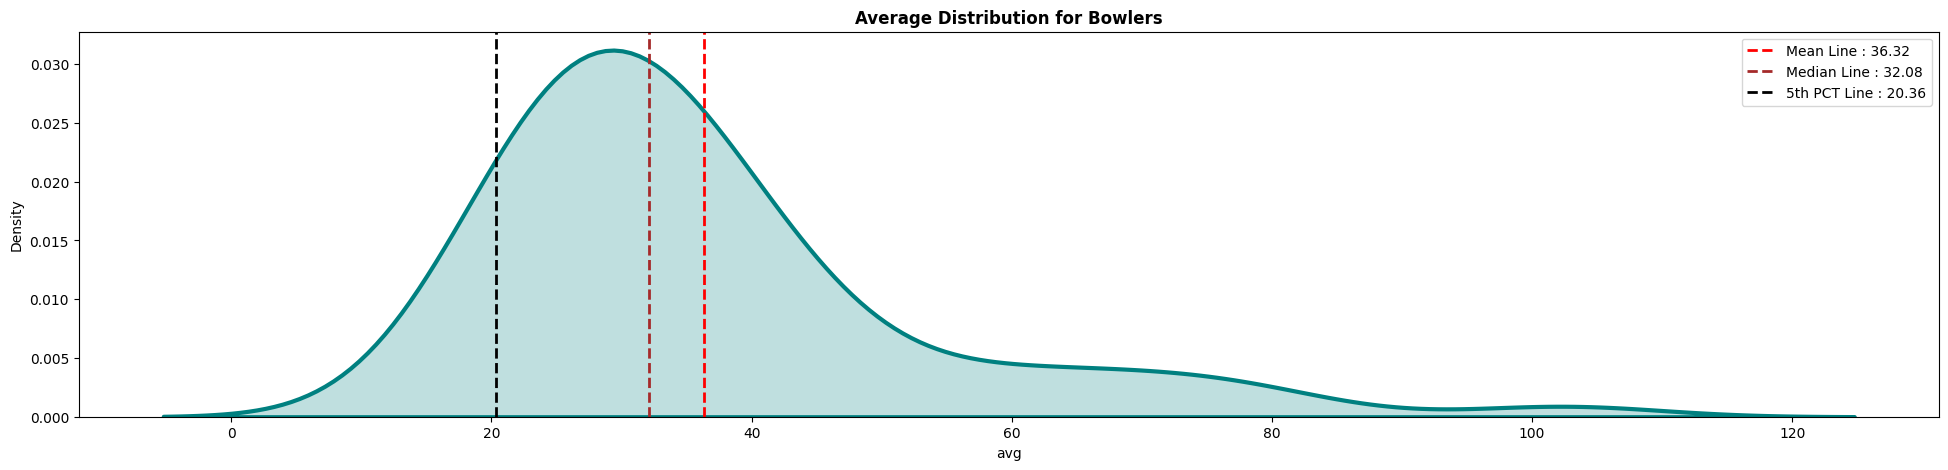

In [64]:
plt.figure(figsize=(24,5))
sns.kdeplot(x ='avg',
            data = bowlers,
            linewidth = 3,
            fill=True,
            color='teal',
            )
plt.axvline(bowlers['avg'].mean(),color = 'red',linestyle = '--',linewidth = 2,label = f"Mean Line : {bowlers['avg'].mean().round(2)}")
plt.axvline(bowlers['avg'].median(),color = 'brown',linestyle = '--',linewidth = 2,label = f"Median Line : {bowlers['avg'].median().round(2)}")
plt.axvline(bowlers['avg'].quantile(.05),color = 'black',linestyle = '--',linewidth = 2,label = f"5th PCT Line : {bowlers['avg'].quantile(.05).round(2)}")


plt.title("Average Distribution for Bowlers",weight = 'bold')
plt.grid(False)
plt.legend()
plt.show()

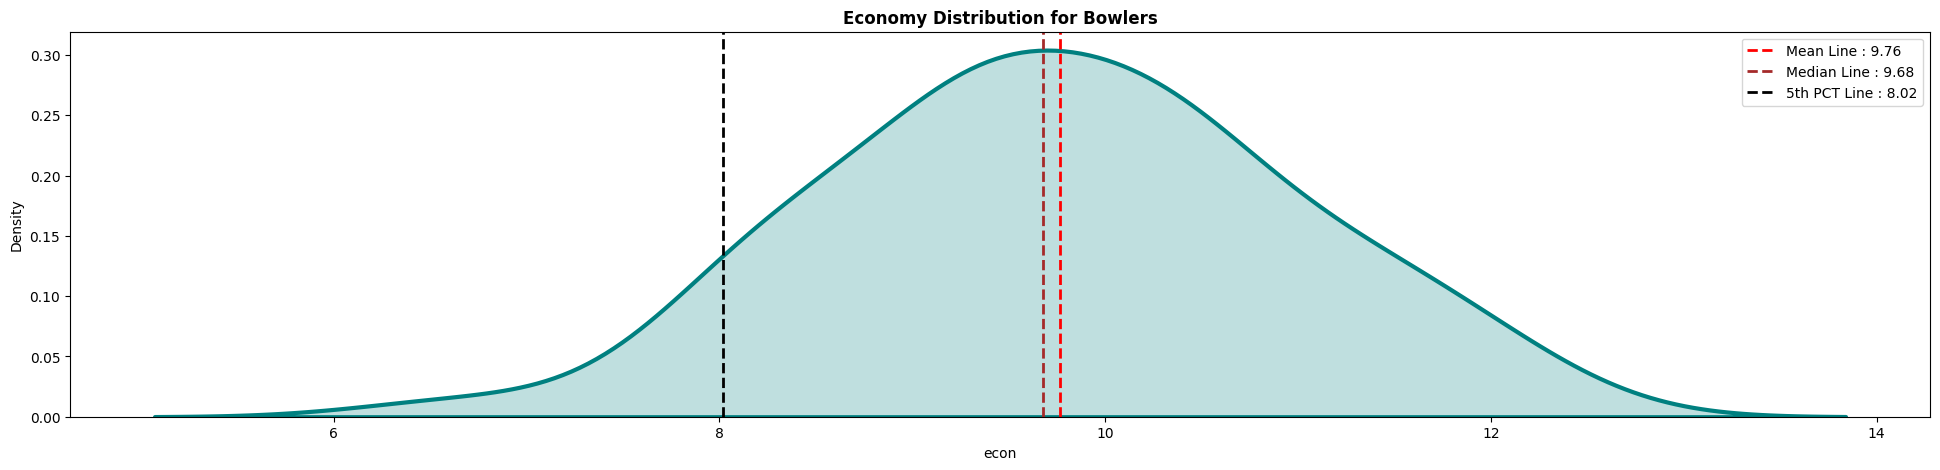

In [65]:
plt.figure(figsize=(24,5))
sns.kdeplot(x ='econ',
            data = bowlers,
            linewidth = 3,
            fill=True,
            color='teal',
            )
plt.axvline(bowlers['econ'].mean(),color = 'red',linestyle = '--',linewidth = 2,label = f"Mean Line : {bowlers['econ'].mean().round(2)}")
plt.axvline(bowlers['econ'].median(),color = 'brown',linestyle = '--',linewidth = 2,label = f"Median Line : {bowlers['econ'].median().round(2)}")
plt.axvline(bowlers['econ'].quantile(.05),color = 'black',linestyle = '--',linewidth = 2,label = f"5th PCT Line : {bowlers['econ'].quantile(.05).round(2)}")


plt.title("Economy Distribution for Bowlers",weight = 'bold')
plt.grid(False)
plt.legend()
plt.show()

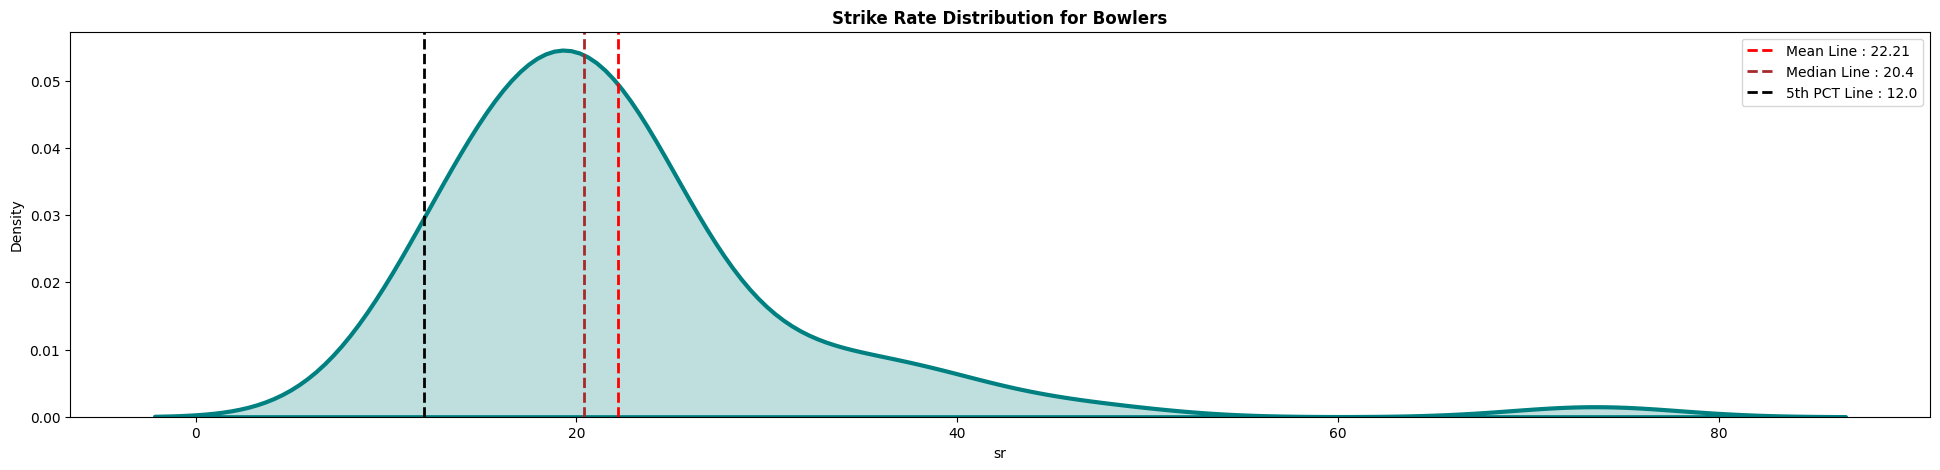

In [66]:
plt.figure(figsize=(24,5))
sns.kdeplot(x ='sr',
            data = bowlers,
            linewidth = 3,
            fill=True,
            color='teal',
            )
plt.axvline(bowlers['sr'].mean(),color = 'red',linestyle = '--',linewidth = 2,label = f"Mean Line : {bowlers['sr'].mean().round(2)}")
plt.axvline(bowlers['sr'].median(),color = 'brown',linestyle = '--',linewidth = 2,label = f"Median Line : {bowlers['sr'].median().round(2)}")
plt.axvline(bowlers['sr'].quantile(.05),color = 'black',linestyle = '--',linewidth = 2,label = f"5th PCT Line : {bowlers['sr'].quantile(.05).round(2)}")


plt.title("Strike Rate Distribution for Bowlers",weight = 'bold')
plt.grid(False)
plt.legend()
plt.show()

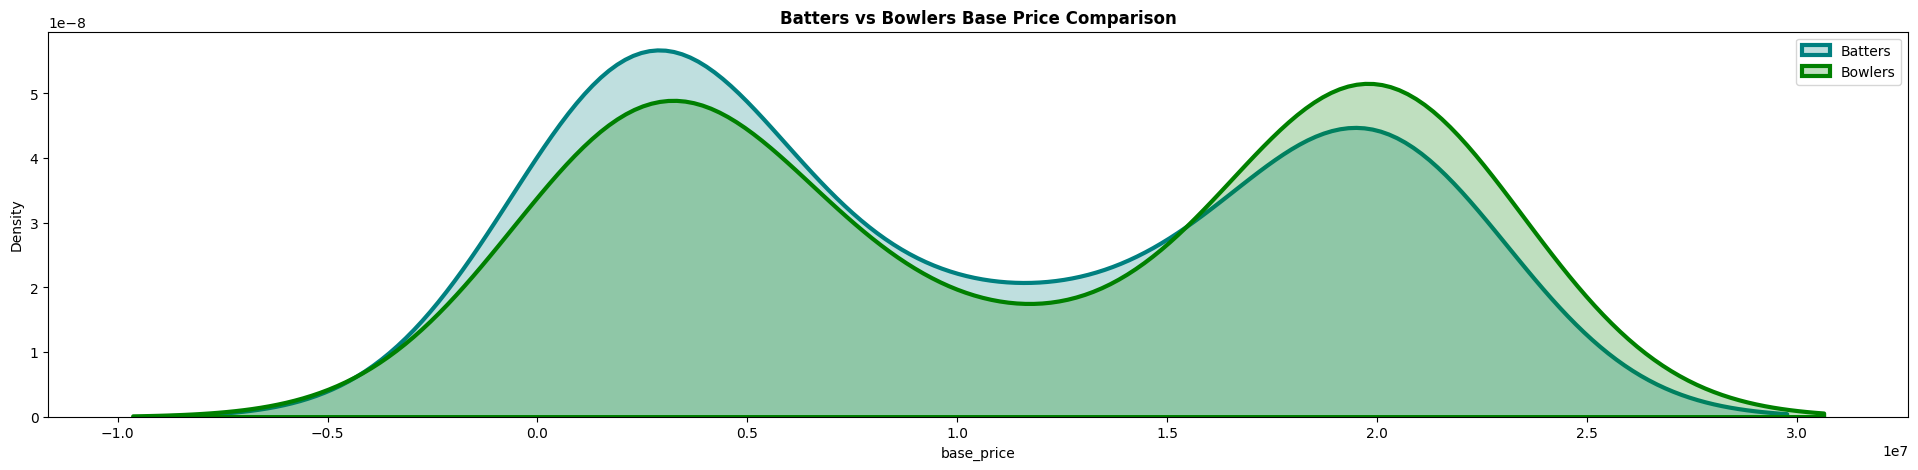

In [68]:
plt.figure(figsize=(24,5))
sns.kdeplot(x ='base_price',
            data = batters,
            linewidth = 3,
            fill=True,
            color='teal',
            label = 'Batters')
sns.kdeplot(x ='base_price',
            data = bowlers,
            linewidth = 3,
            fill=True,
            color='green',
            label = 'Bowlers')
plt.title("Batters vs Bowlers Base Price Comparison",weight = 'bold')
plt.legend()
plt.show()

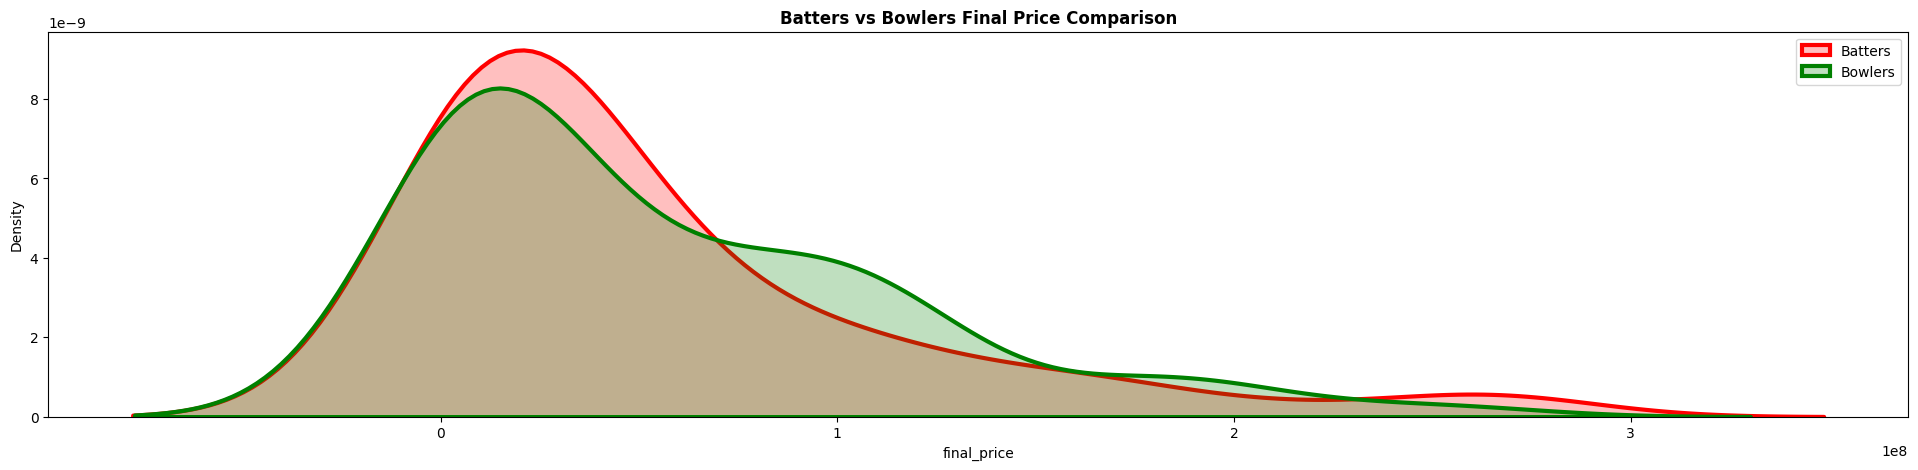

In [71]:
plt.figure(figsize=(24,5))
sns.kdeplot(x ='final_price',
            data = batters,
            linewidth = 3,
            fill=True,
            color='red',
            label = 'Batters')
sns.kdeplot(x ='final_price',
            data = bowlers,
            linewidth = 3,
            fill=True,
            color='green',
            label = 'Bowlers')
plt.title("Batters vs Bowlers Final Price Comparison",weight = 'bold')
plt.legend()
plt.show()

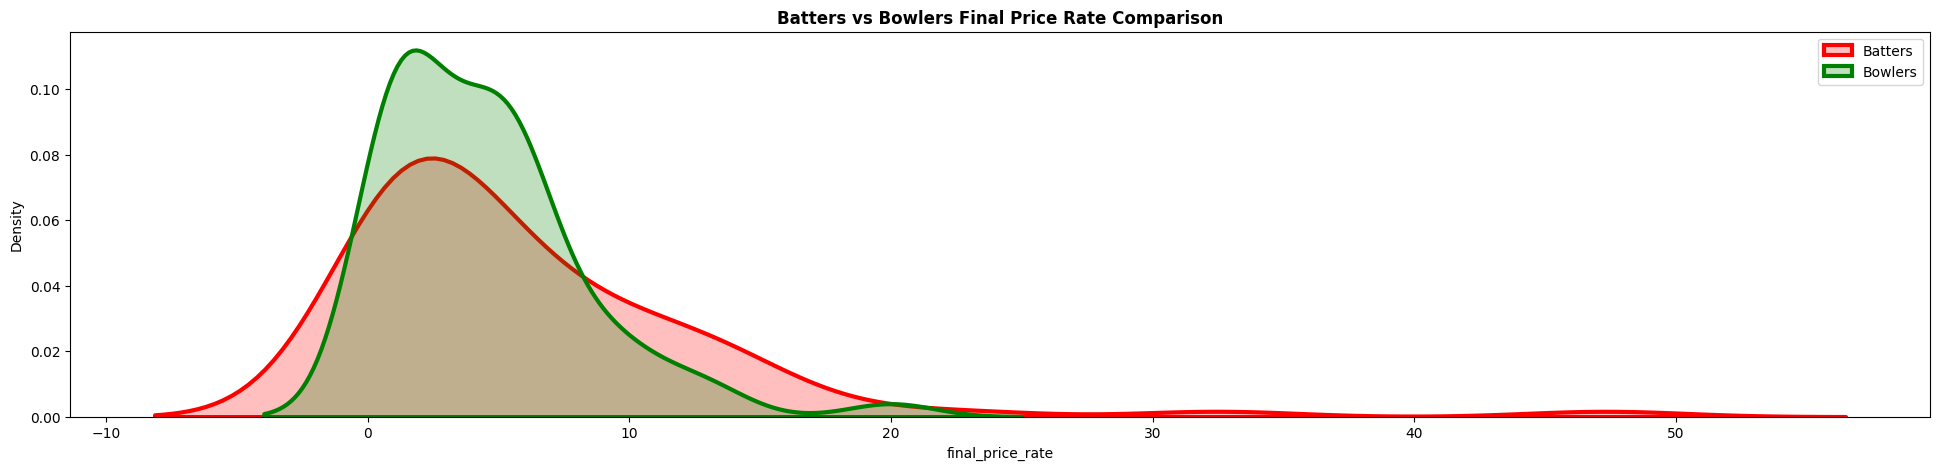

In [72]:
plt.figure(figsize=(24,5))
sns.kdeplot(x ='final_price_rate',
            data = batters,
            linewidth = 3,
            fill=True,
            color='red',
            label = 'Batters')
sns.kdeplot(x ='final_price_rate',
            data = bowlers,
            linewidth = 3,
            fill=True,
            color='green',
            label = 'Bowlers')
plt.title("Batters vs Bowlers Final Price Rate Comparison",weight = 'bold')
plt.legend()
plt.show()

<Figure size 1500x300 with 0 Axes>

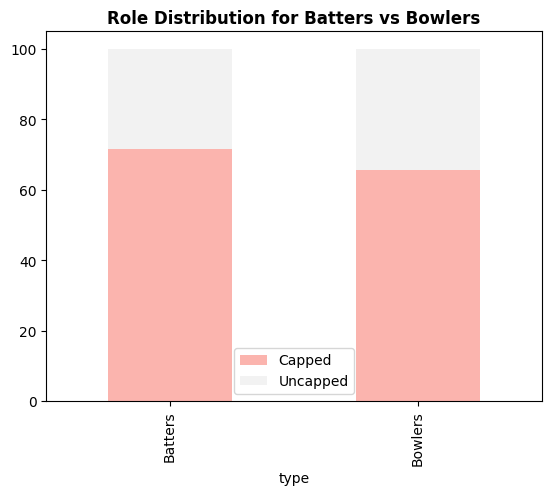

In [83]:
batters_role_dist = batters['role'].value_counts(normalize=True).mul(100).round(2).reset_index(name = 'occurance_pct')
bowlers_role_dist = bowlers['role'].value_counts(normalize=True).mul(100).round(2).reset_index(name = 'occurance_pct')
combined = pd.concat([batters_role_dist, bowlers_role_dist])
combined['type'] = ['Batters']*len(batters_role_dist) + ['Bowlers']*len(bowlers_role_dist)
pivot = combined.pivot(index='type', columns='role', values='occurance_pct').fillna(0)

plt.figure(figsize=(15,3))
ax = pivot.plot(kind='bar', stacked=True, colormap='Pastel1')
plt.title("Role Distribution for Batters vs Bowlers", weight='bold')
plt.legend()
plt.show()

---
---
***Key Findings:***

```Not out more than 4 times, is a good statistics```

```Strike Rate 200 or more keeps a batter in top 5 percentile```

```80% or more boundary percentage keeps a batter in top 5 percentile```

```On average 24 balls per innings keep a batter in top 5```

```Average of 20 or less keeps a bowler in top 5 percentile```

```Economy less than 8 keeps a bowler in top 5 percentile```

```Bowling Strike Rate less than 12 keeps a bowler in top 5 percentile```

```Price Rate goes higher in terms of batters, compared to bowlers```

---
---


### 4.2 Bivariate Analysis

## 5.Justification

### 5.1 Batters

5.1.1 Capped

5.1.2 Uncapped

### 6.1 Bowlers

6.1.1 Capped

6.1.2 Uncapped